# Quickstart: Fit a Galaxy in Under a Minute

This notebook demonstrates the complete diffsed workflow:
1. **Generate** a mock galaxy with a parametric SFH
2. **Fit** it with gradient-based MAP optimization
3. **Add burstiness** with the stochastic GP component

For the full theory behind the IFT-based SFH model, see Tutorial 1.

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, "../src")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from diffsed import (
    Model, ParamSpec, Uniform, Gaussian, Fixed,
    load_ssp_data, load_filter_set,
)

plt.rcParams.update({
    "figure.dpi": 130, "font.size": 11,
    "axes.linewidth": 1.0,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
})

## 1. Setup: Load SSP Templates and Filters

diffsed uses FSPS/MILES stellar population templates with nebular emission, and real photometric filter curves from the SVO Filter Profile Service.

In [2]:
# Load SSP templates (FSPS/MILES with nebular emission, Chabrier IMF)
ssp = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
print(f"SSP templates: {ssp.ssp_flux.shape[0]} metallicities x "
      f"{ssp.ssp_flux.shape[1]} ages x {ssp.ssp_flux.shape[2]} wavelengths")

# Load SDSS photometric filters
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
filter_names = ["u", "g", "r", "i", "z"]

SSP templates: 15 metallicities x 93 ages x 5994 wavelengths


---
## 2. Parametric Model: Smooth SFH

We start with a purely parametric model — a smooth double power-law SFH with dust and metallicity, but **no stochastic burstiness**. This is similar to what codes like BAGPIPES or Prospector use by default.

The `ParamSpec` defines every parameter: `Uniform(lo, hi)` means free with a uniform prior, a bare number means fixed.

In [3]:
# Define the parameter specification
spec = ParamSpec(
    # Star formation history (double power law)
    sfh_alpha        = Uniform(0.5, 3.0),     # falling slope (cosmic time)
    sfh_beta         = Uniform(0.3, 2.0),      # rising slope (cosmic time)
    sfh_tau_peak_gyr = Uniform(0.5, 10.0),     # turnover time [Gyr]
    sfh_peak_sfr     = Uniform(0.1, 50.0),     # peak SFR [Msun/yr]
    # Metallicity
    met_logzsol      = Uniform(-1.5, 0.2),     # log10(Z/Zsun)
    # Dust (Charlot & Fall 2000)
    dust_tau_bc      = Uniform(0.0, 3.0),      # birth cloud optical depth
    dust_tau_diff    = Uniform(0.0, 2.0),       # diffuse ISM optical depth
    dust_slope       = -0.7,                    # fixed power-law index
    # Redshift
    redshift         = 0.1,                     # fixed at z=0.1
    # No stochastic component
    stochastic       = False,
)

print(f"Free parameters: {spec.n_free}")
print(f"Free: {spec.free_params}")
print(f"Fixed: {spec.fixed_params}")

Free parameters: 7
Free: ['dust_tau_bc', 'dust_tau_diff', 'met_logzsol', 'sfh_alpha', 'sfh_beta', 'sfh_peak_sfr', 'sfh_tau_peak_gyr']
Fixed: ['dust_slope', 'psd_sigma', 'psd_tau_myr', 'redshift']


In [4]:
# Create the model
model = Model(spec, ssp, filters=filters)

# Define true parameters for our mock galaxy
true_params = {
    "sfh_alpha": 1.5,           # moderate decline after peak
    "sfh_beta": 1.0,            # steady rise to peak
    "sfh_tau_peak_gyr": 4.0,    # SFH peaks at 4 Gyr lookback
    "sfh_peak_sfr": 8.0,        # 8 Msun/yr at peak
    "met_logzsol": -0.3,        # slightly sub-solar
    "dust_tau_bc": 1.0,         # moderate birth cloud dust
    "dust_tau_diff": 0.3,       # light diffuse dust
    "dust_slope": -0.7,         # Calzetti-like slope
    "redshift": 0.1,
}

# Generate mock observation with SNR=20
mock = model.mock(true_params, snr=20.0, key=jax.random.PRNGKey(0))
print("Mock photometry (erg/s/cm^2/Hz):")
for name, f, n in zip(filter_names, mock.flux_obs, mock.noise):
    print(f"  {name}: {float(f):.3e} +/- {float(n):.3e}")

W0313 22:29:25.120032 2644993 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Mock photometry (erg/s/cm^2/Hz):
  u: 1.426e-28 +/- 7.203e-30
  g: 7.516e-28 +/- 3.911e-29
  r: 1.773e-27 +/- 8.125e-29
  i: 2.283e-27 +/- 1.131e-28
  z: 3.229e-27 +/- 1.608e-28


### Plot the Mock Galaxy: SED and Photometry

The full SED (spectrum) spans UV through near-IR. The 5 SDSS filter points sample this SED at specific wavelengths — this is all the data we have for fitting.

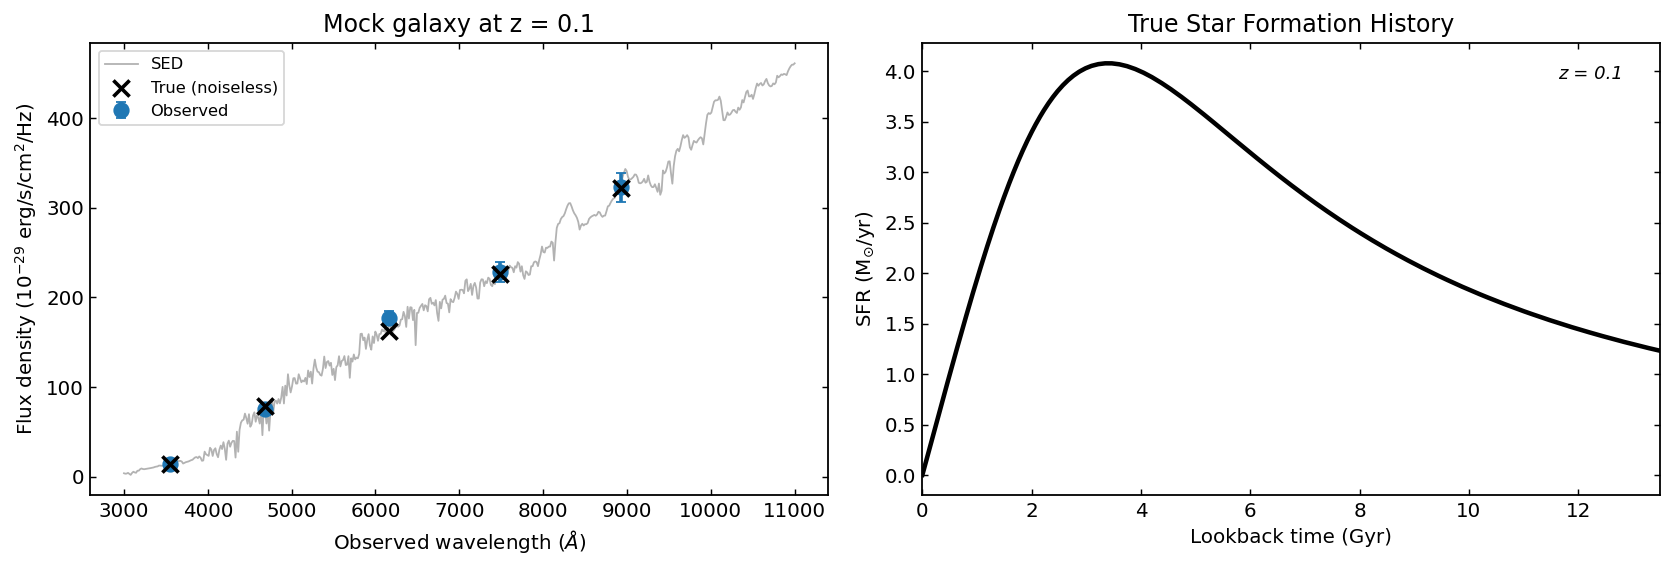

In [5]:
# Compute the full SED for plotting
from diffsed.models.observation.photometry import ab_mag_from_flux
from diffsed.models.observation.spectroscopy import compute_spectrum

# Observed-frame wavelength grid for the SED
wave_obs = jnp.linspace(3000, 11000, 500)  # Angstrom
sed_spectrum = model.predict_spectrum(true_params, wave_obs)

# Effective wavelengths for each filter
wave_eff = jnp.array([3551, 4686, 6166, 7480, 8932])  # SDSS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: SED + photometry
ax1.plot(wave_obs, sed_spectrum * 1e29, color="gray", alpha=0.6, lw=1, label="SED")
ax1.errorbar(wave_eff, mock.flux_obs * 1e29, yerr=mock.noise * 1e29,
             fmt="o", color="C0", ms=8, capsize=3, lw=2, label="Observed")
ax1.scatter(wave_eff, mock.flux_true * 1e29, color="k", marker="x", s=80,
            zorder=10, lw=2, label="True (noiseless)")
ax1.set_xlabel(r"Observed wavelength ($\AA$)")
ax1.set_ylabel(r"Flux density ($10^{-29}$ erg/s/cm$^2$/Hz)")
ax1.set_title(f"Mock galaxy at z = {true_params['redshift']}")
ax1.legend(fontsize=9)

# Right: Star formation history
sfh = model.predict_sfh(true_params)
ax2.plot(sfh["t_gyr"], sfh["sfr_mean"], "k-", lw=2.5)
ax2.set_xlabel("Lookback time (Gyr)")
ax2.set_ylabel(r"SFR (M$_{\odot}$/yr)")
ax2.set_title("True Star Formation History")
ax2.set_xlim(0, 13.5)
ax2.text(0.95, 0.95, f"z = {true_params['redshift']}", transform=ax2.transAxes,
         ha="right", va="top", fontsize=10, style="italic")

plt.tight_layout()
plt.show()

---
## 3. Fit with MAP Optimization

MAP (Maximum A Posteriori) finds the single best-fit parameter set by minimizing the loss function using gradient descent (Adam optimizer). No error bars, but extremely fast — seconds per galaxy.

In [6]:
# Fit the mock data
result = model.fit(
    mock.flux_obs, mock.noise,
    method="map",
    n_steps=2000,
    learning_rate=0.03,
    verbose=True,
)

print(f"\nWall time: {result.wall_time_s:.1f}s")
print(f"Final loss: {result.diagnostics['final_loss']:.2f}")

  Step     0/2000: loss = 193.4303


  Step   200/2000: loss = 2.0148


  Step   400/2000: loss = 1.9841


  Step   600/2000: loss = 1.9458


  Step   800/2000: loss = 1.9017


...

  Step  1200/2000: loss = 1.7992


  Step  1400/2000: loss = 1.7430


  Step  1600/2000: loss = 1.6857


  Step  1800/2000: loss = 1.6290


  Step  1999/2000: loss = 1.5753
  MAP complete in 3.9s

Wall time: 3.9s
Final loss: 1.58


### Results: SFH Recovery and Photometry Fit

The left panel shows the recovered SFH (dashed) vs truth (solid) in **linear** time and SFR — the most intuitive view for observers. The right panel shows the SED with the best-fit photometry overlaid.

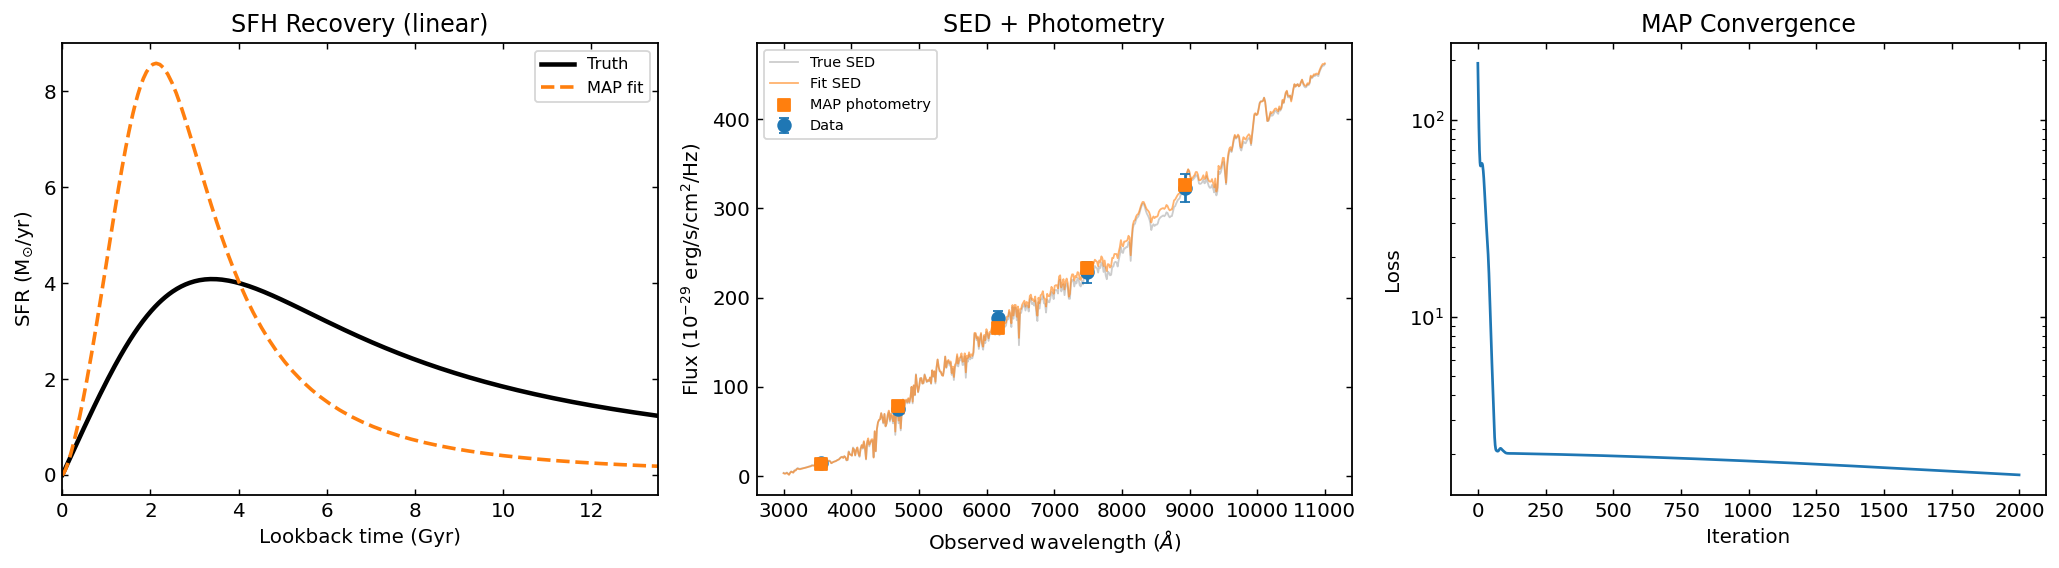

In [7]:
# Compute fitted SFH and photometry
sfh_fit = model.predict_sfh(result.params)
phot_fit = model.predict_photometry(result.params)
sed_fit = model.predict_spectrum(result.params, wave_obs)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Left: SFH recovery (linear scale)
ax = axes[0]
ax.plot(sfh["t_gyr"], sfh["sfr_mean"], "k-", lw=2.5, label="Truth")
ax.plot(sfh_fit["t_gyr"], sfh_fit["sfr_mean"], "C1--", lw=2, label="MAP fit")
ax.set_xlabel("Lookback time (Gyr)")
ax.set_ylabel(r"SFR (M$_{\odot}$/yr)")
ax.set_title("SFH Recovery (linear)")
ax.set_xlim(0, 13.5)
ax.legend(fontsize=9)

# Middle: SED + photometry
ax = axes[1]
ax.plot(wave_obs, sed_spectrum * 1e29, color="gray", alpha=0.4, lw=1, label="True SED")
ax.plot(wave_obs, sed_fit * 1e29, color="C1", alpha=0.6, lw=1, label="Fit SED")
ax.errorbar(wave_eff, mock.flux_obs * 1e29, yerr=mock.noise * 1e29,
             fmt="o", color="C0", ms=7, capsize=3, label="Data")
ax.scatter(wave_eff, phot_fit * 1e29, color="C1", marker="s", s=50,
           zorder=10, label="MAP photometry")
ax.set_xlabel(r"Observed wavelength ($\AA$)")
ax.set_ylabel(r"Flux ($10^{-29}$ erg/s/cm$^2$/Hz)")
ax.set_title("SED + Photometry")
ax.legend(fontsize=8)

# Right: Loss convergence
ax = axes[2]
ax.plot(result.loss_history, "C0", lw=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_title("MAP Convergence")

plt.tight_layout()
plt.show()

In [8]:
# Parameter recovery table
summary = result.summary()
print(f"{'Parameter':<22s} {'True':>10s} {'MAP fit':>10s}")
print("-" * 44)
for name in sorted(true_params.keys()):
    if name in summary:
        true_val = true_params[name]
        fit_val = summary[name]["value"]
        print(f"{name:<22s} {true_val:>10.4g} {fit_val:>10.4g}")

Parameter                    True    MAP fit
--------------------------------------------
dust_slope                   -0.7       -0.7
dust_tau_bc                     1    0.08249
dust_tau_diff                 0.3     0.6572
met_logzsol                  -0.3    -0.6637
redshift                      0.1        0.1
sfh_alpha                     1.5      2.663
sfh_beta                        1      1.411
sfh_peak_sfr                    8      16.35
sfh_tau_peak_gyr                4      2.488


---
## 4. Adding Stochastic Burstiness

Real galaxy SFHs aren't smooth — they have bursts and lulls driven by gas accretion, mergers, and feedback. diffsed models this burstiness as a Gaussian process governed by a power spectral density (PSD).

Two new parameters control the burstiness:
- **`psd_sigma`**: amplitude of SFR fluctuations (in dex)
- **`psd_tau_myr`**: memory timescale — how long a burst episode lasts (in Myr)

The stochastic component adds `n_grid` latent variables (`psd_xi`) that encode the specific burst pattern. This increases the dimensionality substantially, so we recommend **geoVI** (geometric variational inference) over NUTS for posterior sampling.

In [9]:
# Define stochastic model
spec_stoch = ParamSpec(
    sfh_alpha        = Uniform(0.5, 3.0),
    sfh_beta         = Uniform(0.3, 2.0),
    sfh_tau_peak_gyr = Uniform(0.5, 10.0),
    sfh_peak_sfr     = Uniform(0.1, 50.0),
    psd_sigma        = Uniform(0.1, 3.0),      # NOW FREE
    psd_tau_myr      = Uniform(1.0, 300.0),     # NOW FREE
    met_logzsol      = Uniform(-1.5, 0.2),
    dust_tau_bc      = Uniform(0.0, 3.0),
    dust_tau_diff    = Uniform(0.0, 2.0),
    dust_slope       = -0.7,
    redshift         = 0.1,
    stochastic       = True,
    n_grid           = 128,
)

model_stoch = Model(spec_stoch, ssp, filters=filters)

print(f"Free parameters: {spec_stoch.n_free} physical + {spec_stoch.n_grid} psd_xi")
print(f"Total dimensions: {spec_stoch.n_free + spec_stoch.n_grid}")

Free parameters: 9 physical + 128 psd_xi
Total dimensions: 137


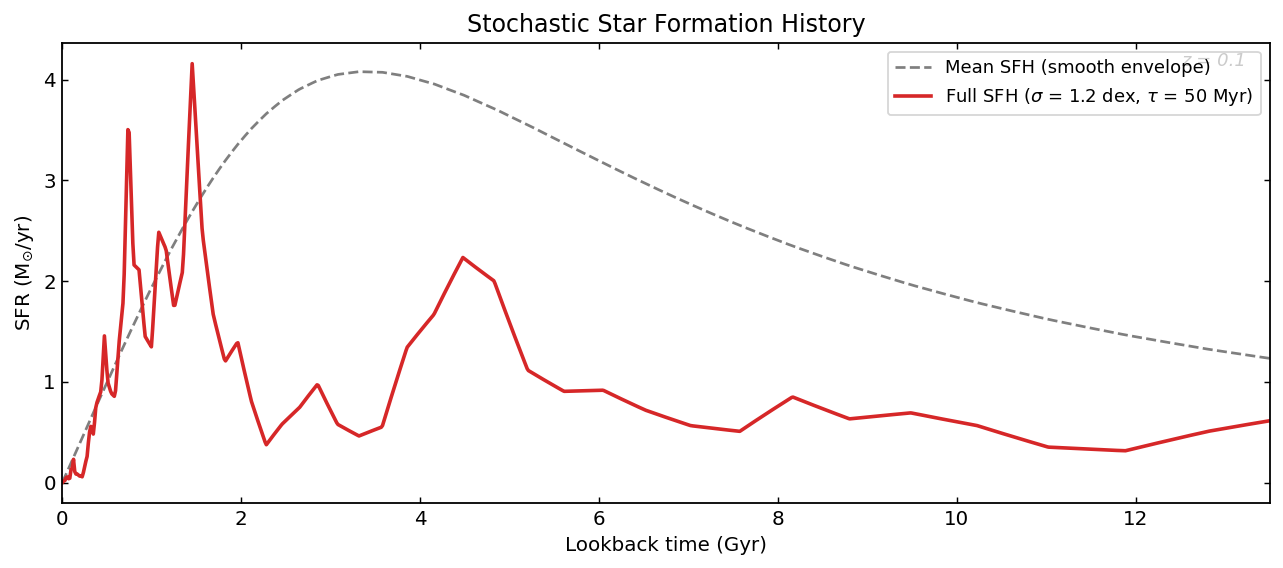

In [10]:
# Generate a bursty mock galaxy
true_stoch = {
    "sfh_alpha": 1.5, "sfh_beta": 1.0,
    "sfh_tau_peak_gyr": 4.0, "sfh_peak_sfr": 8.0,
    "psd_sigma": 1.2,        # moderate burstiness
    "psd_tau_myr": 50.0,     # 50 Myr burst timescale
    "met_logzsol": -0.3,
    "dust_tau_bc": 1.0, "dust_tau_diff": 0.3, "dust_slope": -0.7,
    "redshift": 0.1,
    "psd_xi": jax.random.normal(jax.random.PRNGKey(42), shape=(128,)),
}

mock_stoch = model_stoch.mock(true_stoch, snr=20.0, key=jax.random.PRNGKey(1))

# Plot the bursty SFH
sfh_stoch = model_stoch.predict_sfh(true_stoch)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(sfh_stoch["t_gyr"], sfh_stoch["sfr_mean"], "k--", lw=1.5, alpha=0.5,
        label="Mean SFH (smooth envelope)")
ax.plot(sfh_stoch["t_gyr"], sfh_stoch["sfr_full"], "C3-", lw=2,
        label=r"Full SFH ($\sigma$ = 1.2 dex, $\tau$ = 50 Myr)")
ax.set_xlabel("Lookback time (Gyr)")
ax.set_ylabel(r"SFR (M$_{\odot}$/yr)")
ax.set_title("Stochastic Star Formation History")
ax.set_xlim(0, 13.5)
ax.legend(fontsize=10)
ax.text(0.98, 0.98, f"z = 0.1", transform=ax.transAxes,
        ha="right", va="top", fontsize=10, style="italic")
plt.tight_layout()
plt.show()

  Step     0/2000: loss = 632.4928


  Step   200/2000: loss = 2.1108


  Step   400/2000: loss = 1.3604


  Step   600/2000: loss = 1.0269


  Step   800/2000: loss = 0.8342


...

  Step  1200/2000: loss = 0.6579


  Step  1400/2000: loss = 0.6190


  Step  1600/2000: loss = 0.5931


  Step  1800/2000: loss = 0.5733


  Step  1999/2000: loss = 0.5565
  MAP complete in 4.0s


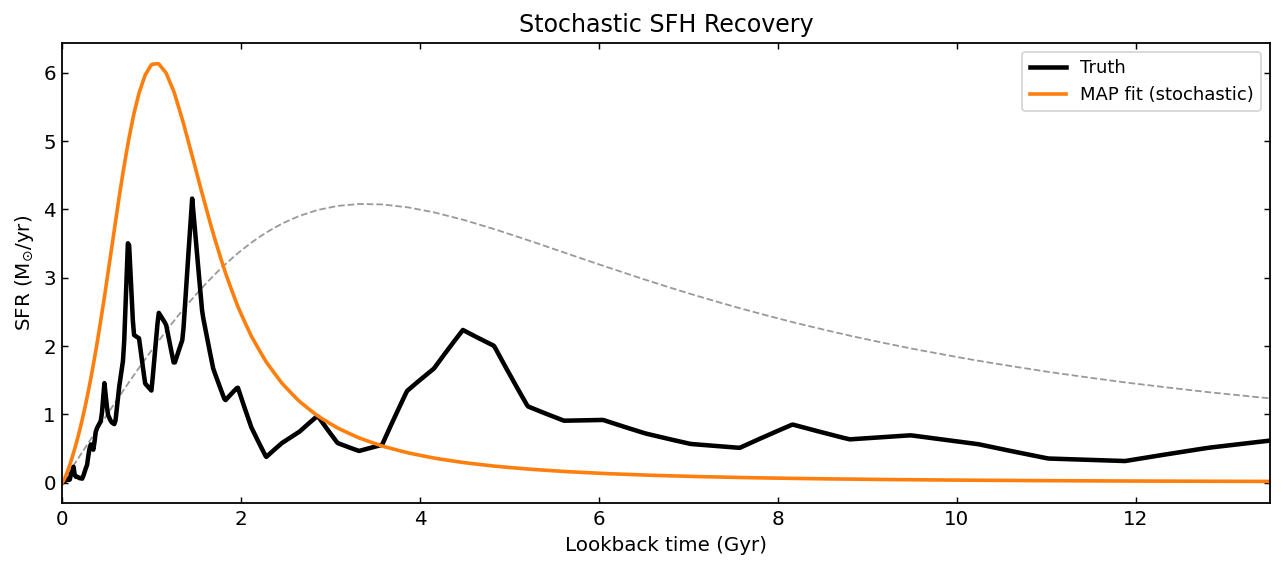

In [11]:
# Fit the stochastic mock with MAP (fast point estimate)
result_stoch = model_stoch.fit(
    mock_stoch.flux_obs, mock_stoch.noise,
    method="map",
    n_steps=2000,
    learning_rate=0.03,
    verbose=True,
)

# Show recovered SFH
sfh_fit_stoch = model_stoch.predict_sfh(result_stoch.params)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(sfh_stoch["t_gyr"], sfh_stoch["sfr_full"], "k-", lw=2.5, label="Truth")
ax.plot(sfh_stoch["t_gyr"], sfh_stoch["sfr_mean"], "k--", lw=1, alpha=0.4)
ax.plot(sfh_fit_stoch["t_gyr"], sfh_fit_stoch["sfr_full"], "C1-", lw=2,
        label="MAP fit (stochastic)")
ax.set_xlabel("Lookback time (Gyr)")
ax.set_ylabel(r"SFR (M$_{\odot}$/yr)")
ax.set_title("Stochastic SFH Recovery")
ax.set_xlim(0, 13.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 5. Posterior Sampling with geoVI

MAP gives a point estimate — no error bars. **geoVI** (geometric variational inference) provides full posterior distributions in seconds. It finds a coordinate transformation where the posterior is approximately Gaussian, enabling efficient sampling even in the 137-dimensional space of the stochastic model.

This is diffsed's primary inference mode for the IFT model.

In [12]:
import sys, io, warnings
warnings.filterwarnings('ignore')

from diffsed import Fitter

fitter_s = Fitter(model_stoch, mock_stoch.flux_obs, mock_stoch.noise)

# geoVI posterior (initialized from MAP for faster convergence)
try:
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    posterior = fitter_s.run(
        "geovi", init_from=result_stoch,
        n_iterations=10, n_samples=8, verbose=False,
    )
    sys.stdout = old_stdout
    print(f"geoVI: {posterior.diagnostics['n_samples']} posterior samples "
          f"in {posterior.wall_time_s:.1f}s")
    print(f"  (137 dimensions: 128 GP latent + 9 physical)")
    geovi_ok = True
except Exception as e:
    sys.stdout = old_stdout
    geovi_ok = False
    print(f"geoVI failed: {e}")
    print("Install nifty8[re] for posterior sampling: pip install nifty8[re]")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


OPTIMIZE_KL: Starting 0001


SL: Iteration 0 ⛰:+4.7163e+03 Δ⛰:inf |∇|:5.8449e+03 ➽:4.0438e-04


SL: Iteration 1 ⛰:-5.8941e+01 Δ⛰:4.7753e+03 |∇|:8.1544e+00 ➽:4.0438e-04


...

MCG: Iteration 5 ⛰:-9.7031e-08 Δ⛰:3.8340e-09 ➽:3.4273e-08 |∇|:4.4037e-03 ➽:1.5734e-03


MCG: Iteration 6 ⛰:-1.0368e-07 Δ⛰:6.6466e-09 ➽:3.4273e-08 |∇|:5.0320e-03 ➽:1.5734e-03


M: →:1.0 ↺:False #∇²:79 |↘|:1.110356e-03 🞋:1.370000e-03
M: Iteration 13 ⛰:+7.191883e+01 Δ⛰:1.039465e-07


OPTIMIZE_KL: Iteration 0010 ⛰:+7.1919e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (4, 6, 4, 5, 5, 4, 3, 3, 4, 6, 4, 4, 5, 4, 4, 4)
OPTIMIZE_KL: #(KL minimization steps) 13
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     0.7±    0.22, avg:  +0.0066±    0.19, #dof:      5'

OPTIMIZE_KL: Prior residual(s):
dust_tau_bc             :: 'reduced χ²:     1.1±    0.73, avg:    +0.03±     1.1, #dof:      1'
dust_tau_diff           :: 'reduced χ²:    0.65±    0.91, avg:    -0.45±    0.67, #dof:      1'
met_logzsol             :: 'reduced χ²:    0.78±    0.58, avg: +4.8e-07±    0.88, #dof:      1'
psd_sigma               :: 'reduced χ²:     1.8±     2.9, avg:    +0.85±     1.1, #dof:      1'
psd_tau_myr             :: 'reduced χ²:    0.35±    0.31, avg:    -0.13±    0.58, #dof:      1'
psd_xi                  :: 'reduced χ²:     1.0±    0.15, avg:   -0.023±   0.061, #dof:    128'
sfh_alpha               :: 'reduced χ²:     1.3±     1.0, avg:    +0.27±     1.1, #dof:      1'
sfh_beta        

geoVI: 16 posterior samples in 87.1s
  (137 dimensions: 128 GP latent + 9 physical)


### Posterior SFH with Uncertainties

The spread of posterior SFH draws shows where the data constrains the star formation history and where it doesn't.

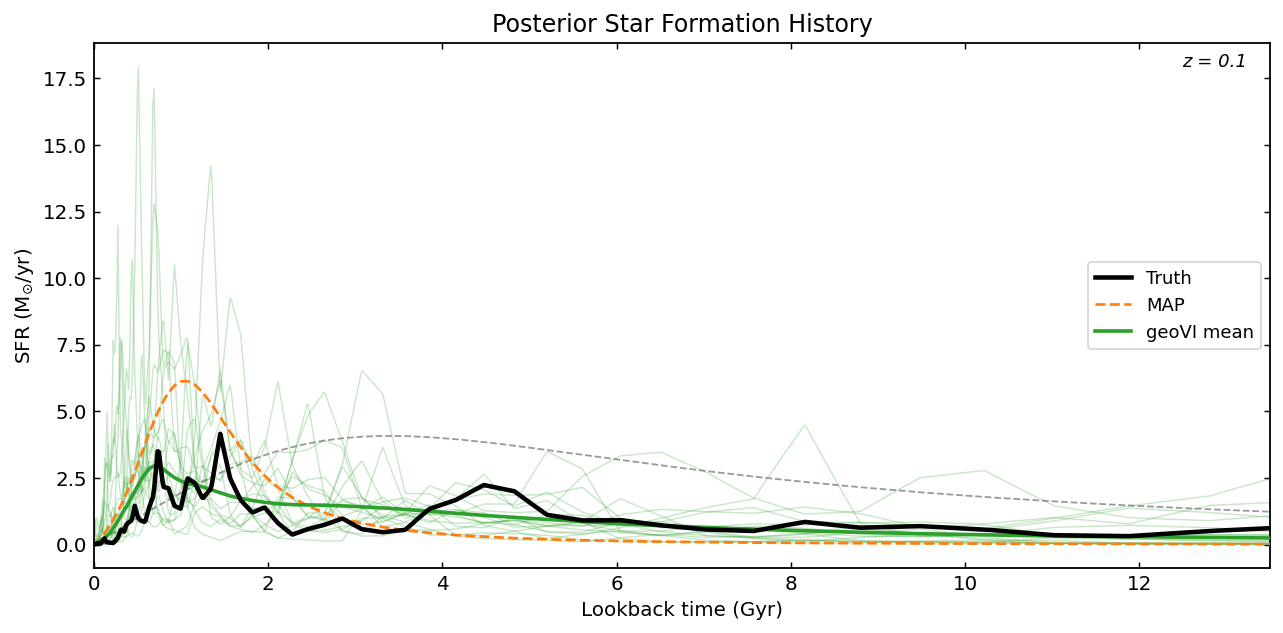

In [13]:
if geovi_ok:
    fig, ax = plt.subplots(figsize=(10, 5))

    # Truth
    ax.plot(sfh_stoch["t_gyr"], sfh_stoch["sfr_full"], "k-", lw=2.5, label="Truth", zorder=10)
    ax.plot(sfh_stoch["t_gyr"], sfh_stoch["sfr_mean"], "k--", lw=1, alpha=0.4)

    # Posterior SFH draws
    n_draw = posterior.diagnostics["n_samples"]
    for i in range(n_draw):
        s_i = {k: posterior.samples[k][i] for k in posterior.samples}
        sfh_i = model_stoch.predict_sfh(s_i)
        ax.plot(sfh_i["t_gyr"], sfh_i["sfr_full"], "C2-", alpha=0.25, lw=0.8)

    # MAP
    ax.plot(sfh_fit_stoch["t_gyr"], sfh_fit_stoch["sfr_full"], "C1--", lw=1.5, label="MAP", zorder=8)

    # Posterior mean
    sfh_post_mean = model_stoch.predict_sfh(posterior.params)
    ax.plot(sfh_post_mean["t_gyr"], sfh_post_mean["sfr_full"], "C2-", lw=2, label="geoVI mean", zorder=9)

    ax.set_xlabel("Lookback time (Gyr)")
    ax.set_ylabel(r"SFR (M$_{\odot}$/yr)")
    ax.set_title("Posterior Star Formation History")
    ax.set_xlim(0, 13.5)
    ax.legend(fontsize=10)
    ax.text(0.98, 0.98, "z = 0.1", transform=ax.transAxes,
            ha="right", va="top", fontsize=10, style="italic")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping — geoVI not available")

### Posterior Spectrum with Uncertainties

Each posterior sample predicts a different SED. The spread shows the spectral uncertainty.

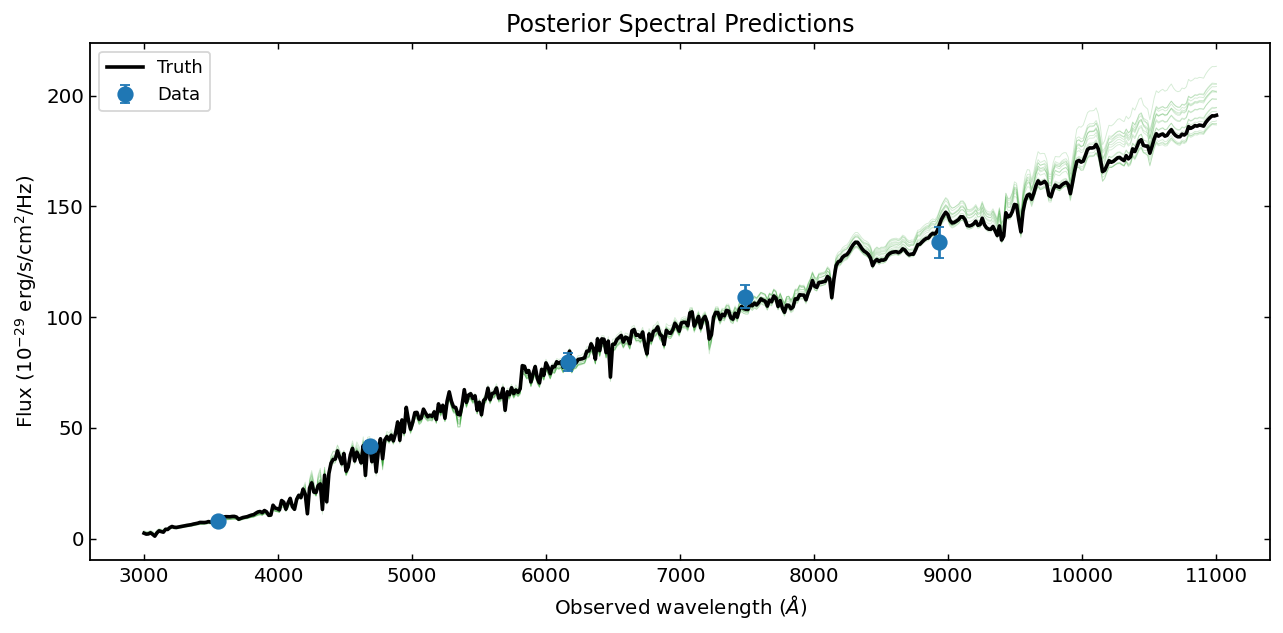

In [14]:
if geovi_ok:
    fig, ax = plt.subplots(figsize=(10, 5))

    wave_plot = jnp.linspace(3000, 11000, 500)

    # True spectrum
    sed_true = model_stoch.predict_spectrum(true_stoch, wave_plot)
    ax.plot(wave_plot, sed_true * 1e29, "k-", lw=2, label="Truth", zorder=10)

    # Posterior SED draws
    n_draw = posterior.diagnostics["n_samples"]
    sed_draws = []
    for i in range(n_draw):
        s_i = {k: posterior.samples[k][i] for k in posterior.samples}
        sed_i = model_stoch.predict_spectrum(s_i, wave_plot)
        sed_draws.append(np.array(sed_i))
        ax.plot(wave_plot, sed_i * 1e29, "C2-", alpha=0.2, lw=0.5)

    # Data
    ax.errorbar(wave_eff, mock_stoch.flux_obs * 1e29, yerr=mock_stoch.noise * 1e29,
                fmt="o", color="C0", ms=8, capsize=3, zorder=10, label="Data")

    ax.set_xlabel(r"Observed wavelength ($\AA$)")
    ax.set_ylabel(r"Flux ($10^{-29}$ erg/s/cm$^2$/Hz)")
    ax.set_title("Posterior Spectral Predictions")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping — geoVI not available")

### Parameter Posteriors

The marginal posterior distributions for the physical parameters. The dashed lines show the true values.

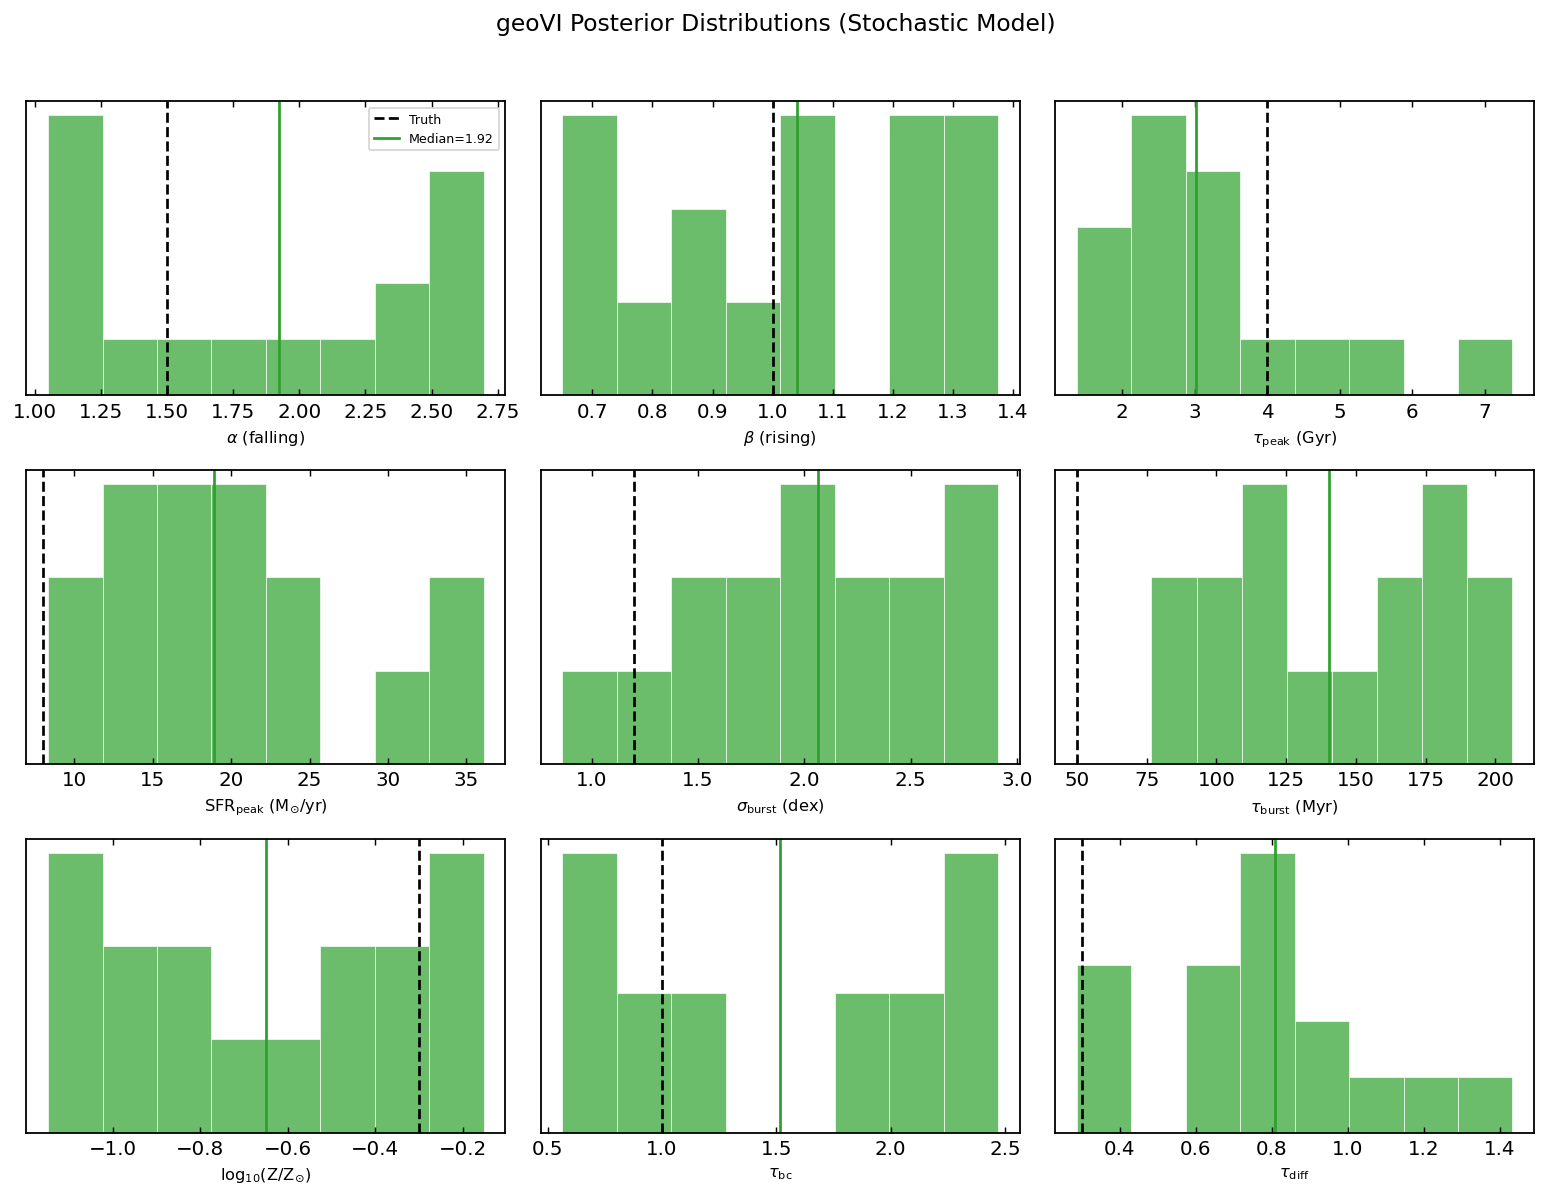

Parameter                  True   Median    lo_68    hi_68
--------------------------------------------------
sfh_alpha                   1.5     1.92     1.21     2.54
sfh_beta                      1     1.04    0.761      1.3
sfh_tau_peak_gyr              4     3.02     2.01     4.27
sfh_peak_sfr                  8     18.9     12.2     27.9
psd_sigma                   1.2     2.07      1.5      2.6
psd_tau_myr                  50      140     97.3      185
met_logzsol                -0.3    -0.65    -1.04   -0.262
dust_tau_bc                   1     1.52    0.702     2.33
dust_tau_diff               0.3     0.81    0.523     0.99


In [15]:
if geovi_ok:
    param_info = [
        ("sfh_alpha",         r"$\alpha$ (falling)",           1.5),
        ("sfh_beta",          r"$\beta$ (rising)",             1.0),
        ("sfh_tau_peak_gyr",  r"$\tau_{\rm peak}$ (Gyr)",     4.0),
        ("sfh_peak_sfr",      r"SFR$_{\rm peak}$ (M$_{\odot}$/yr)", 8.0),
        ("psd_sigma",         r"$\sigma_{\rm burst}$ (dex)",  1.2),
        ("psd_tau_myr",       r"$\tau_{\rm burst}$ (Myr)",    50.0),
        ("met_logzsol",       r"log$_{10}$(Z/Z$_{\odot}$)",   -0.3),
        ("dust_tau_bc",       r"$\tau_{\rm bc}$",             1.0),
        ("dust_tau_diff",     r"$\tau_{\rm diff}$",           0.3),
    ]

    n_p = len(param_info)
    fig, axes = plt.subplots(3, 3, figsize=(12, 9))
    axes = axes.ravel()

    for idx, (key, label, true_val) in enumerate(param_info):
        ax = axes[idx]
        if key in posterior.samples:
            vals = np.array(posterior.samples[key])
            n_bins = min(15, max(5, len(vals) // 2))
            ax.hist(vals, bins=n_bins, color="C2", alpha=0.7, density=True,
                    edgecolor="white", lw=0.5)
            ax.axvline(true_val, color="k", ls="--", lw=1.5, label="Truth")
            med = np.median(vals)
            ax.axvline(med, color="C2", ls="-", lw=1.5, label=f"Median={med:.2f}")
        ax.set_xlabel(label, fontsize=9)
        ax.set_yticks([])
        if idx == 0:
            ax.legend(fontsize=7)

    fig.suptitle("geoVI Posterior Distributions (Stochastic Model)", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # Summary table
    s = posterior.summary()
    print(f"{'Parameter':<22s} {'True':>8s} {'Median':>8s} {'lo_68':>8s} {'hi_68':>8s}")
    print("-" * 50)
    for key, label, true_val in param_info:
        if key in s and 'median' in s[key]:
            print(f"{key:<22s} {true_val:>8.3g} {s[key]['median']:>8.3g} "
                  f"{s[key]['lo_68']:>8.3g} {s[key]['hi_68']:>8.3g}")
else:
    print("Skipping — geoVI not available")

---
## 5. Derived Quantities

Because the full pipeline is differentiable, we can compute derived quantities (stellar mass, SFR, sSFR) and their gradients analytically.

In [16]:
# Derived quantities for the parametric fit
derived_true = model.predict_derived(true_params)
derived_fit = model.predict_derived(result.params)

print(f"{'Quantity':<20s} {'True':>12s} {'MAP fit':>12s}")
print("-" * 46)
for key in ["stellar_mass", "sfr_100myr", "sfr_10myr", "ssfr"]:
    t = float(derived_true[key])
    f = float(derived_fit[key])
    if key == "stellar_mass":
        print(f"{key:<20s} {t:>12.3e} {f:>12.3e}  Msun")
    elif key == "ssfr":
        print(f"{key:<20s} {t:>12.3e} {f:>12.3e}  yr^-1")
    else:
        print(f"{key:<20s} {t:>12.3f} {f:>12.3f}  Msun/yr")

Quantity                     True      MAP fit
----------------------------------------------
stellar_mass            3.361e+10    3.127e+10  Msun
sfr_100myr                  0.043        0.027  Msun/yr
sfr_10myr                   0.008        0.002  Msun/yr
ssfr                    1.286e-12    8.721e-13  yr^-1


---
## 6. Gradient Sensitivity: Which Bands Constrain Which Parameters?

Because the entire pipeline is JAX-differentiable, we can compute the exact Jacobian $\partial f_{\rm band} / \partial \theta$ via automatic differentiation.

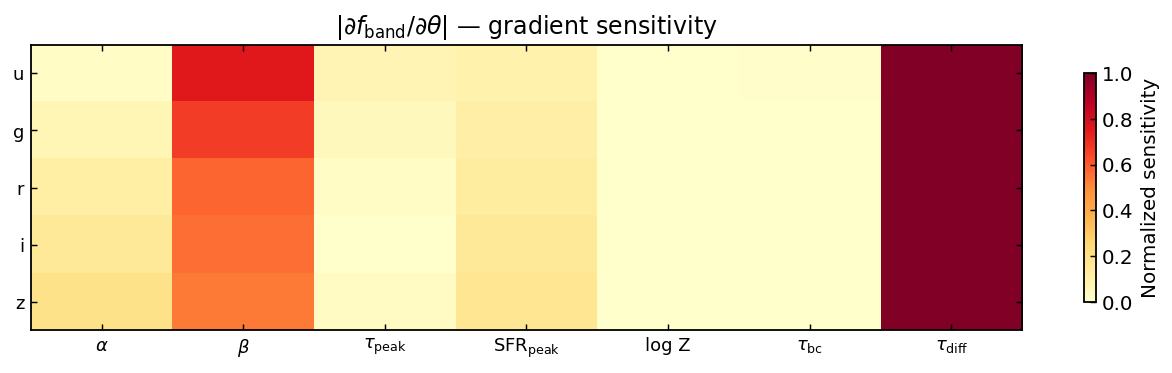

In [17]:
# Compute Jacobian of photometry w.r.t. physical parameters
param_names_jac = ["sfh_alpha", "sfh_beta", "sfh_tau_peak_gyr", "sfh_peak_sfr",
                   "met_logzsol", "dust_tau_bc", "dust_tau_diff"]

def phot_from_vec(vec):
    p = dict(true_params)
    for i, name in enumerate(param_names_jac):
        p[name] = vec[i]
    return model.predict_photometry(p)

vec = jnp.array([float(true_params[n]) for n in param_names_jac])
jac = jax.jacobian(phot_from_vec)(vec)

# Normalize per band
jac_norm = jnp.abs(jac) / jnp.max(jnp.abs(jac), axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(jac_norm, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(param_names_jac)))
ax.set_xticklabels([r"$\alpha$", r"$\beta$", r"$\tau_{\rm peak}$",
                     r"SFR$_{\rm peak}$", r"log Z",
                     r"$\tau_{\rm bc}$", r"$\tau_{\rm diff}$"], fontsize=10)
ax.set_yticks(range(5))
ax.set_yticklabels(filter_names, fontsize=10)
ax.set_title(r"$|\partial f_{\rm band} / \partial \theta|$ — gradient sensitivity")
plt.colorbar(im, ax=ax, shrink=0.8, label="Normalized sensitivity")
plt.tight_layout()
plt.show()

---
## What's Next

- **Tutorial 1**: The IFT-based SFH model in depth — PSD, GP, correlated fields
- **Tutorial 2**: Dust, SSPs, and the complete forward model
- **Tutorial 3**: Generating mock galaxy catalogs
- **Tutorial 4**: Fitting with photometry, spectroscopy, and joint constraints
- **Tutorial 5**: Inference comparison — MAP vs NUTS vs geoVI